# TODO 5.6.

- put all scaling options into a single result CSV (no separate directories) 

In [2]:
import pandas as pd
import h5py

from pathlib import Path
from itertools import product
from IPython.display import clear_output

from aipad.padimputer import PADImputer
from aipad.spacecrafts import SoloConstants, WindConstants
from aipad.datahandler import WindDataHandler
from aipad.pad_imputation import (
    make_train_test, calculate_PAD)

In [3]:
bins = 8
time_avg_min = 1
avg_bin = f"{time_avg_min}min_{bins}bins"

file_path = Path("./data/hdf5") / f"wind_{avg_bin}.h5"
cov_path = Path("./data/coverages") / avg_bin
plot_path = Path(f"./plots/")

plot_path.mkdir(exist_ok=True)

solo = SoloConstants()
wind = WindConstants()

### Simple imputation strategies: row/column mean, average of forward and backward fill, linear interpolation, KNN without train-test split


In [9]:
scale = "log+minmax"
results_path = Path(f"./results/mcar/{scale}")
results_path.mkdir(exist_ok=True)

imputer = PADImputer(wind, missingness="mcar")

miss_pcts = [20, 30, 40, 50, 60, 70]
methods = ["mean", "fill_average", "interp", "knn"]
axes = ["time", "pitch_angle"]

events = pd.read_csv("events.csv")
for event_no in range(len(events)):
    event_key = events.values[event_no][0]
    # if event_key.split("-")[0] < "20121214":
    #     continue
    for method, axis, miss_pct in product(methods, axes, miss_pcts):
        imputer.axis = 0 if axis == "time" else 1
        imputer._knn_neighbors = 15 if axis == "time" else 5
        imputer.method = method
        plot_path = Path(f"./plots/mcar/{imputer.method}/{axis}")
        plot_path.mkdir(exist_ok=True, parents=True)
        imputer.run_analysis(event_key, miss_pct=miss_pct, repeats=1, scale=scale,
                                fname=f"{event_key}_{imputer.method}_axis{imputer.axis}_{miss_pct}pct",
                                file_path=file_path, results_path=results_path, plot_path=plot_path,
                                show_plot=False, save_plot=False)
    #clear_output()

Event 20120102-153731 with 20.000 % MCAR missingness: results using method 'mean' along time axis
NRMSE: 0.094
Event 20120102-153731 with 30.000 % MCAR missingness: results using method 'mean' along time axis
NRMSE: 0.100
Event 20120102-153731 with 40.000 % MCAR missingness: results using method 'mean' along time axis
NRMSE: 0.094
Event 20120102-153731 with 50.000 % MCAR missingness: results using method 'mean' along time axis
NRMSE: 0.093
Event 20120102-153731 with 60.000 % MCAR missingness: results using method 'mean' along time axis
NRMSE: 0.093
Event 20120102-153731 with 70.000 % MCAR missingness: results using method 'mean' along time axis
NRMSE: 0.096
Event 20120102-153731 with 20.000 % MCAR missingness: results using method 'mean' along pitch_angle axis
NRMSE: 0.083
Event 20120102-153731 with 30.000 % MCAR missingness: results using method 'mean' along pitch_angle axis
NRMSE: 0.074
Event 20120102-153731 with 40.000 % MCAR missingness: results using method 'mean' along pitch_angl

miss_percent                    20        30        40        50        60  \
method       axis                                                            
mean         time         0.199440  0.194944  0.192978  0.192085  0.194141   
             pitch_angle  0.113851  0.112369  0.115062  0.115824  0.118384   
fill_average time         0.022389  0.024100  0.025632  0.028105  0.030345   
             pitch_angle  0.055918  0.064143  0.072170  0.082737  0.094570   
interp       time         0.021235  0.022025  0.023725  0.025730  0.027914   
             pitch_angle  0.053777  0.060723  0.068374  0.078897  0.091239   
knn          time         0.043783  0.051141  0.058330  0.064207  0.068399   
             pitch_angle  0.105943  0.108691  0.112248  0.114617  0.119128   

miss_percent                    70  
method       axis                   
mean         time         0.191771  
             pitch_angle  0.123605  
fill_average time         0.034497  
             pitch_angle  0.106454

/tmp/ipykernel_13395/448871249.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc="upper left")


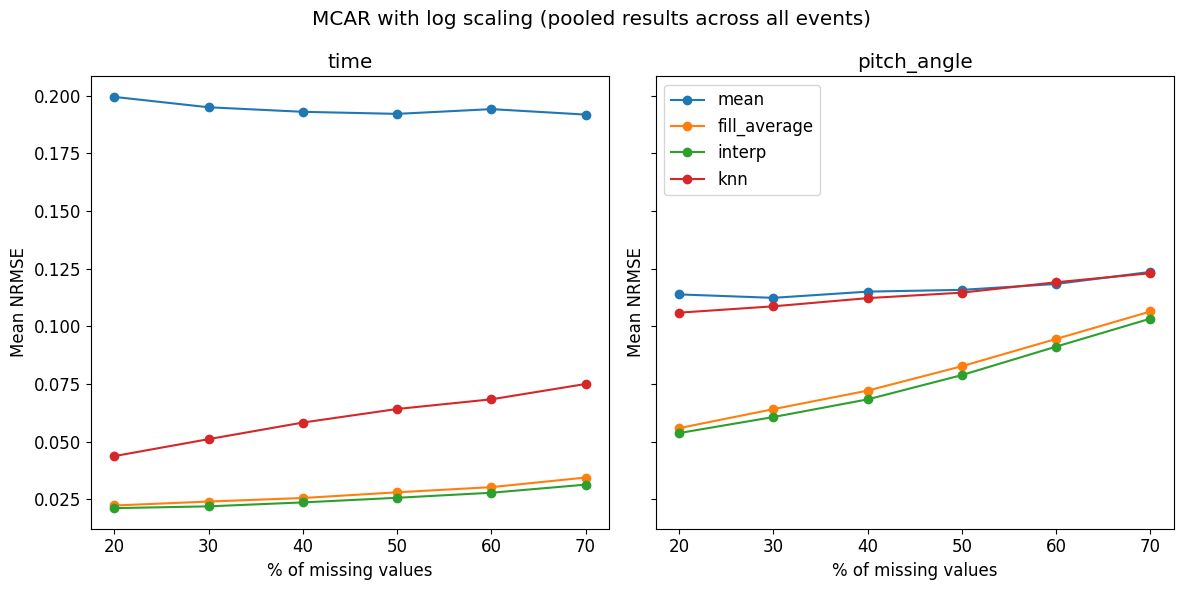

miss_percent                    20        30        40        50        60  \
method       axis                                                            
mean         time         0.185740  0.181327  0.179613  0.179148  0.180399   
             pitch_angle  0.113486  0.112213  0.114944  0.115746  0.118616   
fill_average time         0.022281  0.024082  0.025538  0.028192  0.030248   
             pitch_angle  0.055669  0.064162  0.072218  0.082945  0.094821   
interp       time         0.021101  0.021894  0.023562  0.025610  0.027815   
             pitch_angle  0.053784  0.060800  0.068552  0.079146  0.091546   
knn          time         0.045254  0.052408  0.059335  0.064850  0.068881   
             pitch_angle  0.104504  0.107982  0.111992  0.114692  0.119446   

miss_percent                    70  
method       axis                   
mean         time         0.178058  
             pitch_angle  0.123935  
fill_average time         0.034253  
             pitch_angle  0.106634

/tmp/ipykernel_13395/448871249.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc="upper left")


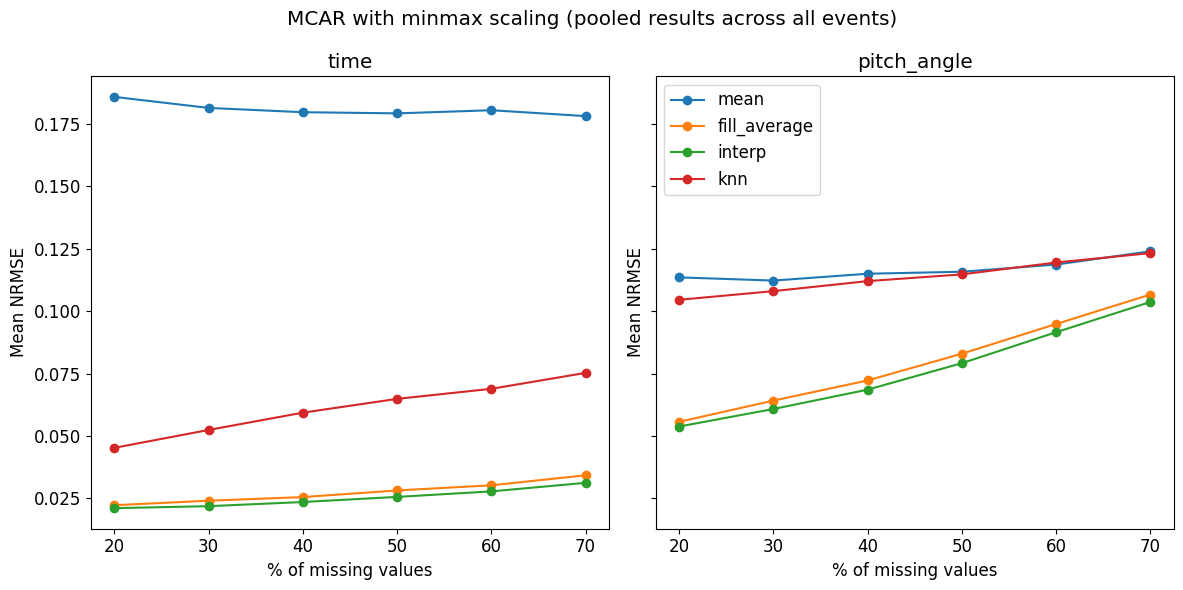

miss_percent                    20        30        40        50        60  \
method       axis                                                            
mean         time         0.185740  0.181327  0.179613  0.179148  0.180399   
             pitch_angle  0.113486  0.112213  0.114944  0.115746  0.118616   
fill_average time         0.022281  0.024082  0.025538  0.028192  0.030248   
             pitch_angle  0.055669  0.064162  0.072218  0.082945  0.094821   
interp       time         0.021101  0.021894  0.023562  0.025610  0.027815   
             pitch_angle  0.053784  0.060800  0.068552  0.079146  0.091546   
knn          time         0.045254  0.052408  0.059335  0.064850  0.068881   
             pitch_angle  0.104504  0.107982  0.111992  0.114692  0.119446   

miss_percent                    70  
method       axis                   
mean         time         0.178058  
             pitch_angle  0.123935  
fill_average time         0.034253  
             pitch_angle  0.106634

/tmp/ipykernel_13395/448871249.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc="upper left")


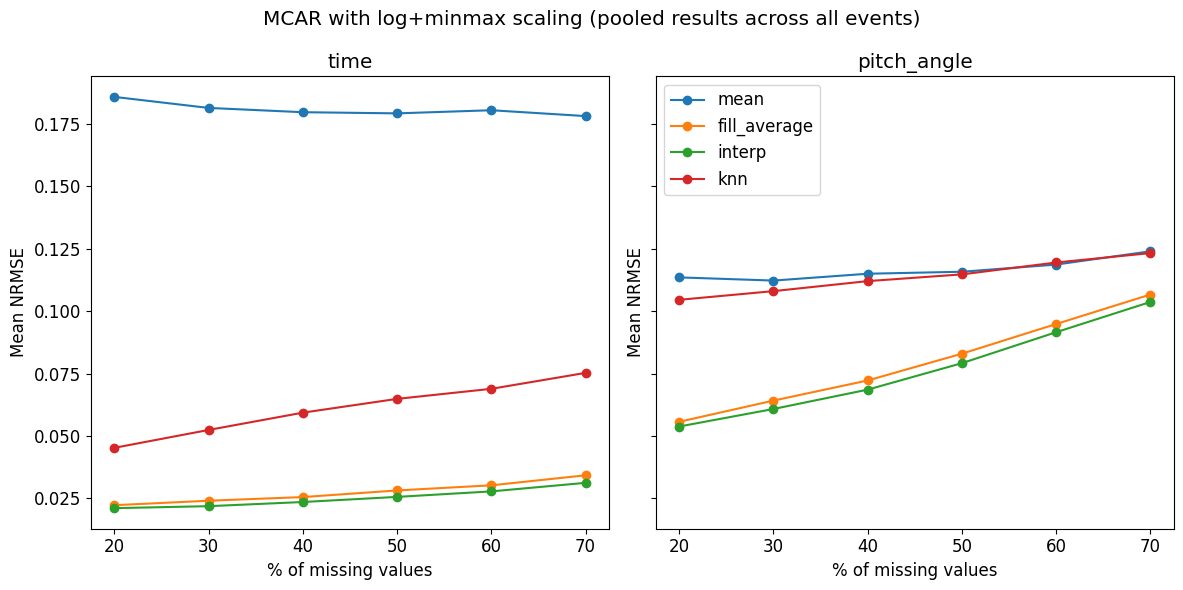

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os

row_vars = ["time", "pitch_angle"]
col_vars = ["mean", "fill_average", "interp", "knn"]

for scale in ["log", "minmax", "log+minmax"]:

    fig, axs = plt.subplots(ncols=2, figsize=(12, 6), sharex=True, sharey=True)
    fig.suptitle(f"MCAR with {scale} scaling (pooled results across all events)")

    results_path = Path(f"./results/mcar/{scale}")
    means = pd.read_csv(results_path / "20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_mean"]

    dfs_mean = []
    for i, csv in enumerate(os.listdir(results_path)):
        dfs_mean.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_mean"].to_numpy())

    means.iloc[:] = np.nanmean(np.stack(dfs_mean), axis=0)
    print(means)
    pcts = means.columns.astype(int)
    # Plot data
    for i, axis in enumerate(row_vars):
        for method in col_vars:
            axs[i].errorbar(pcts, means.loc[(method, axis)].values, yerr=None, fmt="o-", capsize=5, label=f"{method}")
        axs[i].set_title(axis)
        axs[i].set_xlabel(r"% of missing values")
        axs[i].set_ylabel("Mean NRMSE")

        axs[1].legend(loc="upper left")
    plt.tight_layout()
    plt.show()

### MAR data (WIND intensity masked with SolO coverage)

In [5]:
scale = "log+minmax"   # "log", "minmax" or "log+minmax"
results_path = Path(f"./results/mar/{scale}")
results_path.mkdir(exist_ok=True, parents=True)

imputer = PADImputer(spacecraft=wind, missingness="mar")
methods = ["mean", "fill_average", "interp", "knn"]
axes = ["time", "pitch_angle"]

events = pd.read_csv("events.csv")
for i, event_key_ in events.iterrows():
    event_key = event_key_.iloc[0]
    # if event_key.split("-")[0] < "20140219":
    #     continue
    for method, axis in product(methods, axes):
        imputer.axis = 0 if axis == "time" else 1
        imputer.method = method
        plot_path = Path(f"./plots/mar/{imputer.method}/{axis}")
        plot_path.mkdir(exist_ok=True, parents=True)
        imputer.run_analysis(event_key, sc_like="solo", repeats=1, opening=52.8, scale=scale, normalize_rmse=True,
                             show_plot=False, save_plot=False,
                             fname=f"{event_key}_{imputer.method}_axis{imputer.axis}",
                             file_path=file_path, results_path=results_path, plot_path=plot_path)

Event 20120102-153731 with 30.833 % MAR missingness: results using method 'mean' along time axis
NRMSE: 0.135
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'mean' along pitch_angle axis
NRMSE: 0.085
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'fill_average' along time axis
NRMSE: 0.110
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'fill_average' along pitch_angle axis
NRMSE: 0.038
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'interp' along time axis
NRMSE: 0.109
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'interp' along pitch_angle axis
NRMSE: 0.039
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'knn' along time axis
NRMSE: 0.100
Event 20120102-153731 with 30.833 % MAR missingness: results using method 'knn' along pitch_angle axis
NRMSE: 0.083
Event 20120122-030734 with 22.795 % MAR missingness: results using method 

In [13]:
# Read results from CSVs, pool results
for scale in ["log", "minmax", "log+minmax"]:
    results_path = Path(f"/home/ojsant/gradu/results/mar/{scale}")
    means_mar = pd.read_csv(results_path / "20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_mean"]

    dfs = []

    for i, csv in enumerate(os.listdir(results_path)):
        dfs.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_mean"].to_numpy())

    means_mar.iloc[:] = np.mean(np.stack(dfs), axis=0)
    print(means_mar)

miss_percent                    10
method       axis                 
mean         time         0.227726
             pitch_angle  0.120593
fill_average time         0.075334
             pitch_angle  0.059097
interp       time         0.070772
             pitch_angle  0.058439
knn          time         0.076594
             pitch_angle  0.113829
miss_percent                    10
method       axis                 
mean         time         0.214009
             pitch_angle  0.118662
fill_average time         0.075399
             pitch_angle  0.059431
interp       time         0.071391
             pitch_angle  0.058791
knn          time         0.076302
             pitch_angle  0.111123
miss_percent                    10
method       axis                 
mean         time         0.214009
             pitch_angle  0.118662
fill_average time         0.075399
             pitch_angle  0.059431
interp       time         0.071391
             pitch_angle  0.058791
knn          time   

### KNN with vs. without training

In [4]:
import subprocess

for scale in ["log", "log+min_max"]:
    for n_neighbors in [1, 5, 15, 20]:
        for miss_pct in [20, 30, 40, 50, 60, 70]:
            rc = subprocess.run(("python3", "knn_train_test_analysis.py",
                                "mar", str(miss_pct), str(n_neighbors), scale, "123"))
            clear_output()

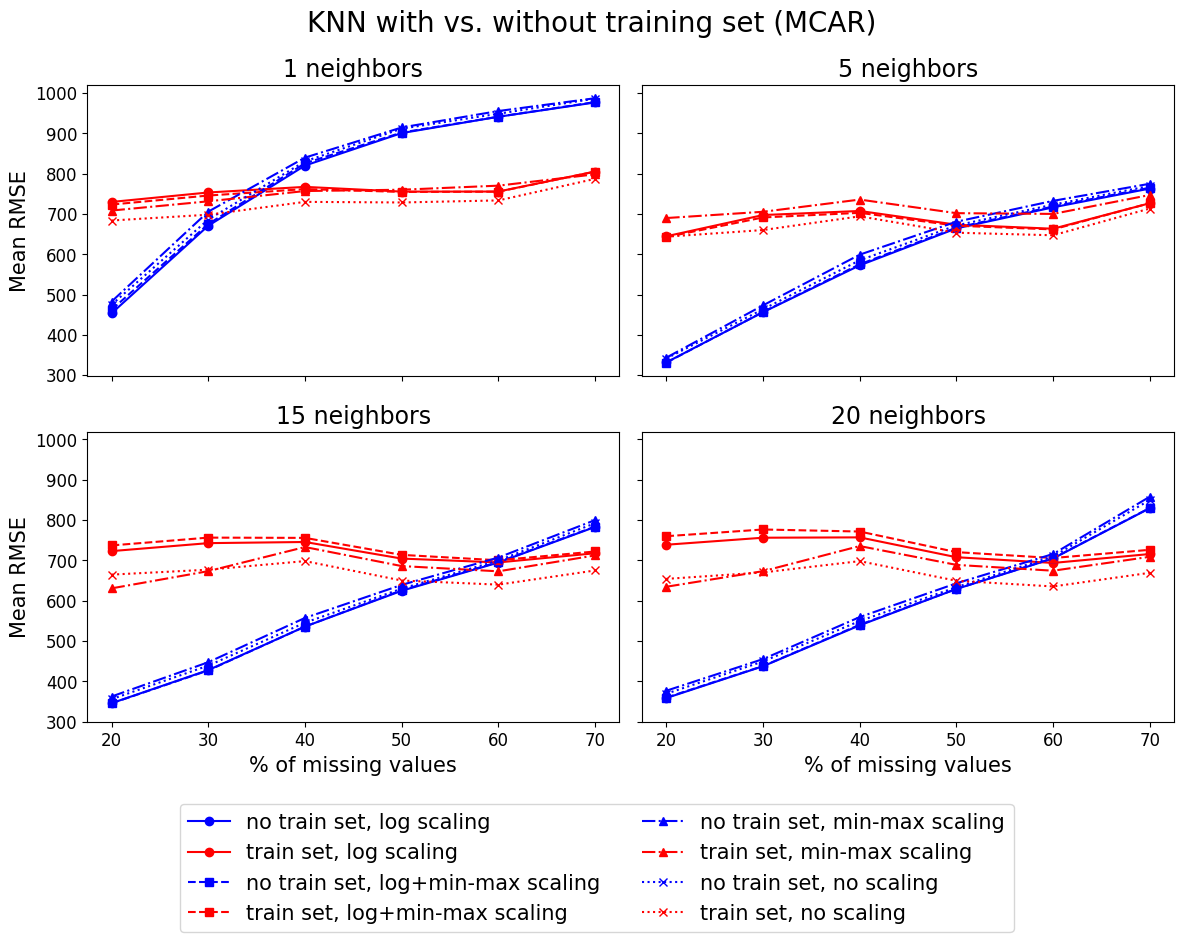

In [66]:
# MCAR plot
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np
import os
import pandas as pd
from itertools import product

label_fs = 15
title_fs = 20
subtitle_fs = 17
legend_fs = 15

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle(f"KNN with vs. without training set (MCAR)", fontsize=title_fs)

markers = ['o', 's', '^', 'x']
styles = ['-', '--', '-.', ':']

for i, n_neighbors in enumerate([1, 5, 15, 20]):
    # Plot data
    ax = axs.ravel()[i]
    for j, scale in enumerate(["log", "log+min_max", "min_max", "none"]):
        results_path = Path(f"./_results/knn_results/mcar/{scale}")

        means = pd.read_csv(results_path / "20120127-183733.csv", header=[0, 1], index_col=[0, 1]).xs(scale, level=1, axis=1)

        dfs = []
        for i, csv in enumerate(os.listdir(results_path)):
            try:
                dfs.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1]).xs(scale, level=1, axis=1).values)
            except IsADirectoryError:
                continue

        dfs = np.stack(dfs)
        mean_rmses = np.mean(dfs, axis=0)
        means.iloc[:] = mean_rmses

        pcts = means.columns.astype(int)

        ax.plot(pcts, means.loc[("knn", n_neighbors)].values,
                color="blue",
                marker=markers[j],
                linestyle=styles[j],
                label=f"no train set, {scale.replace("_", "-") + " scaling" if scale != "none" else "no scaling"}")
        
        ax.plot(pcts, means.loc[("knn_with_traintest", n_neighbors)].values,
                color="red",
                marker=markers[j],
                linestyle=styles[j],
                label=f"train set, {scale.replace("_", "-") + " scaling" if scale != "none" else "no scaling"}")

    ax.set_title(f"{n_neighbors} neighbors", fontsize=subtitle_fs)

axs[0, 0].set_ylabel("Mean RMSE", fontsize=label_fs)
axs[1, 0].set_ylabel("Mean RMSE", fontsize=label_fs)
axs[1, 0].set_xlabel(r"% of missing values", fontsize=label_fs)
axs[1, 1].set_xlabel(r"% of missing values", fontsize=label_fs)

handles, labels = axs.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.86, 0), fontsize=legend_fs, ncol=2)
plt.tight_layout()

In [ ]:
# Read results from CSVs, pool results

dfs = []
for j, scale in enumerate(["log", "log+min_max", "min_max", "none"]):
    results_path = Path(f"./results/knn_results/mcar/{scale}")
    for i, csv in enumerate(os.listdir(results_path)):
        dfs.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1]).values)

means.iloc[:] = np.mean(np.stack(dfs), axis=0)
means

miss_pct                        20                                 30  \
scale                          log min_max log+min_max none      none   
method             n_neighbors                                          
knn                1           NaN     NaN         NaN  NaN  0.077490   
                   5           NaN     NaN         NaN  NaN  0.053816   
                   15          NaN     NaN         NaN  NaN  0.050214   
                   20          NaN     NaN         NaN  NaN  0.050400   
knn_with_traintest 1           NaN     NaN         NaN  NaN  0.132382   
                   5           NaN     NaN         NaN  NaN  0.109392   
                   15          NaN     NaN         NaN  NaN  0.105372   
                   20          NaN     NaN         NaN  NaN  0.105397   

miss_pct                              40        50        60        70  
scale                               none      none      none      none  
method             n_neighbors                                          
knn                1            0.086524  0.089644  0.091596  0.094068  
                   5            0.062718  0.068020  0.071060  0.073699  
                   15           0.057946  0.063493  0.068151  0.073971  
                   20           0.057721  0.063445  0.068567  0.077375  
knn_with_traintest 1            0.121679  0.115840  0.111261  0.109205  
                   5            0.101952  0.092599  0.089680  0.089937  
                   15           0.097853  0.089238  0.086604  0.086118  
                   20           0.097505  0.088800  0.086126  0.085705

Event 20120122-030734 with 50 % MCAR missingness: results using method 'cubic2d' along pitch_angle axis
RMSE mean: 0.035
RMSE std: 0.001


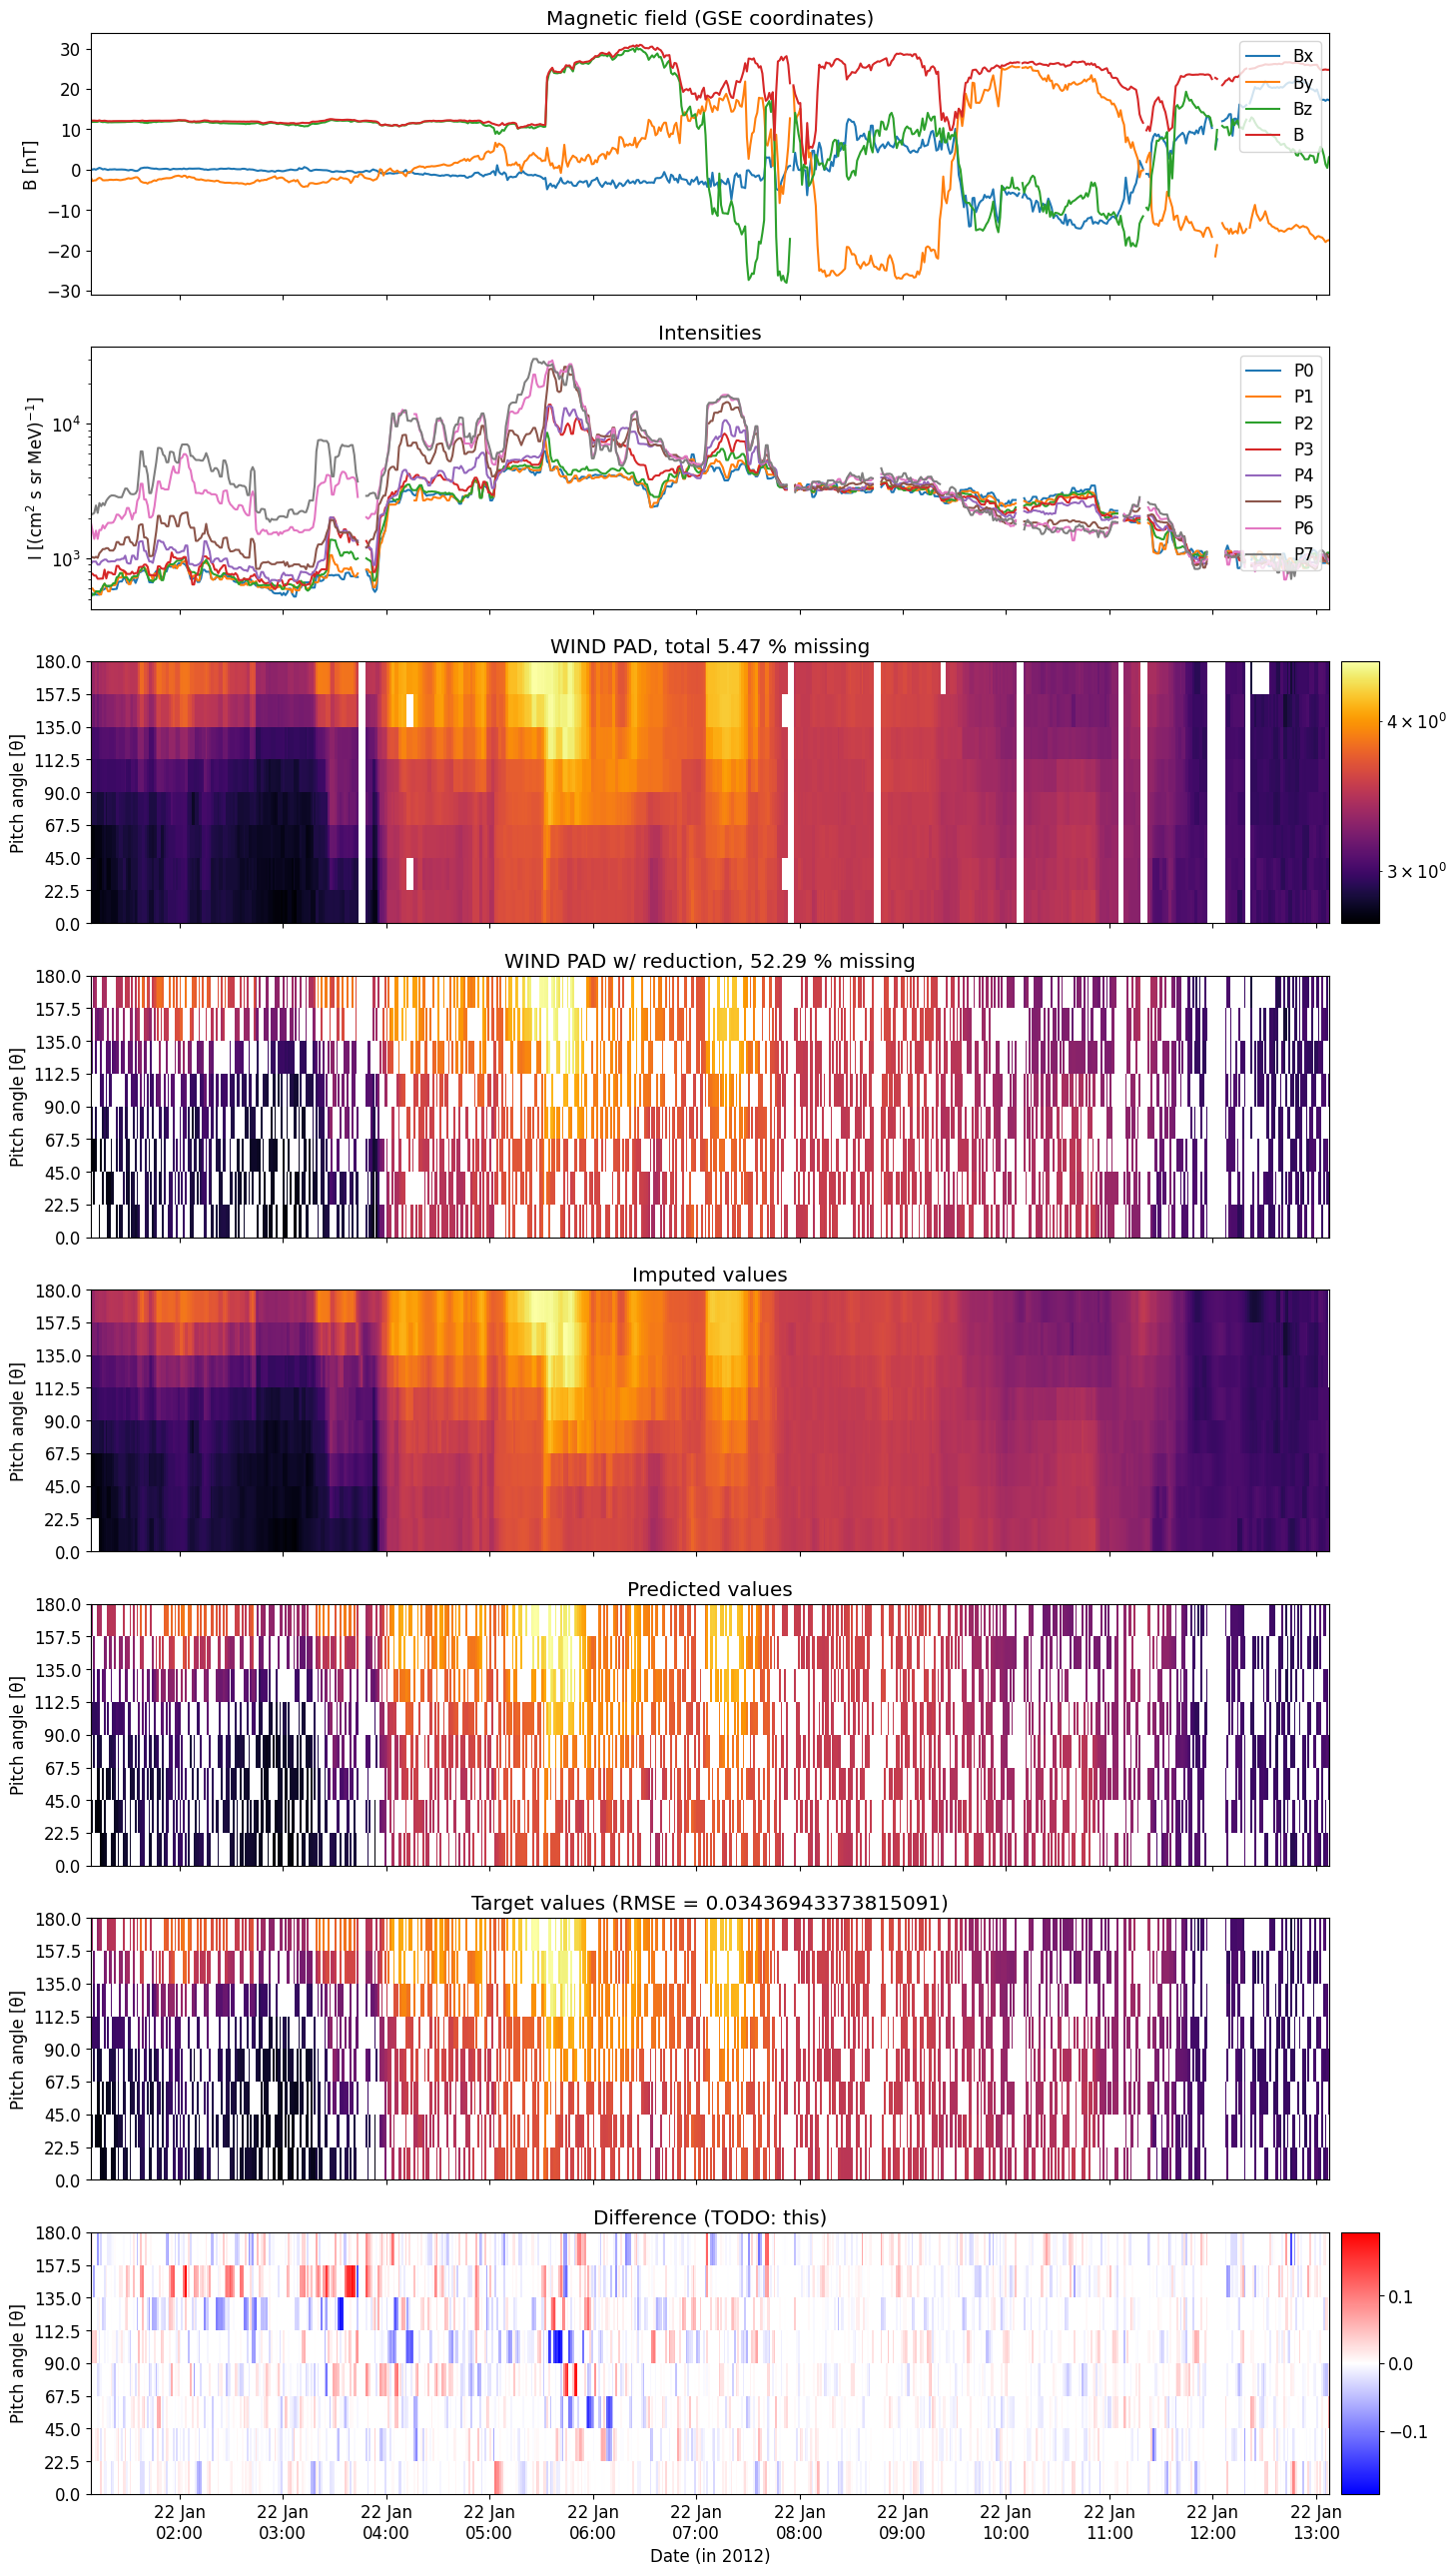

In [4]:
sc = WindConstants()
imputer = PADImputer(sc, method="cubic2d")
repeats = 100
miss_pct = 50
with h5py.File(file_path, 'r') as hdf:
    event_list = list(hdf.keys())
    event_key = event_list[1]
    imputer.run_analysis(event_key, miss_pct, repeats, scale="log", save_plot=False, file_path=file_path,
                         results_path=Path("."))

In [ ]:
from aipad.padimputer import angle_between
from aipad.pad_imputation import convert_to_bool_coverage

imputer = PADImputer(wind, missingness="mar")
events = pd.read_csv("events.csv", header=0)
#event_key = "20120423-005245"
with h5py.File(file_path, 'r') as hdf:
    for i, event_key in events.iterrows():
        onset_dt = pd.to_datetime(event_key.iloc[0])
        imputer.load_event_data(hdf, event_key.iloc[0], wind)
        B_data = imputer.event_data["MagField"]
        start_index = len(B_data[(B_data.index < onset_dt)])
        B_data_12hrs = B_data.iloc[start_index-2*60:start_index+10*60]
        
        cov = PADImputer.calc_coverage(B_data, "solo")
        X, Y, bool_cov = convert_to_bool_coverage(cov, solo, bins=180)
        # fig, ax = plt.subplots(figsize=(16,6))
        
        # ax.pcolormesh(X, Y, bool_cov)

(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(720, 4)
(